In [1]:
import pandas as pd

PATH = "00_data/" 
payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")


In [47]:
##기간에 따른 판매트랜드 확인!

In [2]:
#구매건수: orders
#매출집계 : payments   => 병합하기

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [5]:
#결측치 제거

orders.info()
#orders = orders.dropna()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [6]:
import pandas as pd

merged_order = pd.merge(orders, payments,on ="order_id")

In [8]:
merged_order_payment_date = merged_order[["order_purchase_timestamp","payment_value"]].copy()

In [10]:
merged_order_payment_date

merged_order_payment_date["order_purchase_timestamp"]= pd.to_datetime(merged_order_payment_date["order_purchase_timestamp"], format = "%Y-%m-%d %H:%M:%S", errors="raise")

In [13]:
#형변환 하기
#merged_order_payment_date.info()

#인덱스로 설정
merged_order_payment_date= merged_order_payment_date.set_index("order_purchase_timestamp")

In [14]:
merged_order_payment_date

,payment_value
order_purchase_timestamp,
2017-10-02 10:56:33,18.12
2017-10-02 10:56:33,2.00
2017-10-02 10:56:33,18.59
2018-07-24 20:41:37,141.46
2018-08-08 08:38:49,179.12
...,...
2017-03-09 09:54:05,85.08
2018-02-06 12:58:58,195.00
2017-08-27 14:46:43,271.01


In [17]:
#pandas_25-260416파일: 인덱스키가 되기 전, 일반 열을 기준으로 그룹퍼 생성
#pandas_26_260416파일: 이미 인덱스 키가 된 요소를 기준으로 그룹퍼를 생성(굳이 key 매개변수 불필요) 

merged_order_month_count = merged_order_payment_date.groupby(pd.Grouper(freq= "ME")).count()
df_list = df.groupby(pd.Grouper)

In [18]:
merged_order_month_count

,payment_value
order_purchase_timestamp,
2016-10-31,287
2016-11-30,0
2016-12-31,1
2017-01-31,797
2017-02-28,1737
2017-03-31,2700
2017-04-30,2436
2017-05-31,3786
2017-06-30,3323


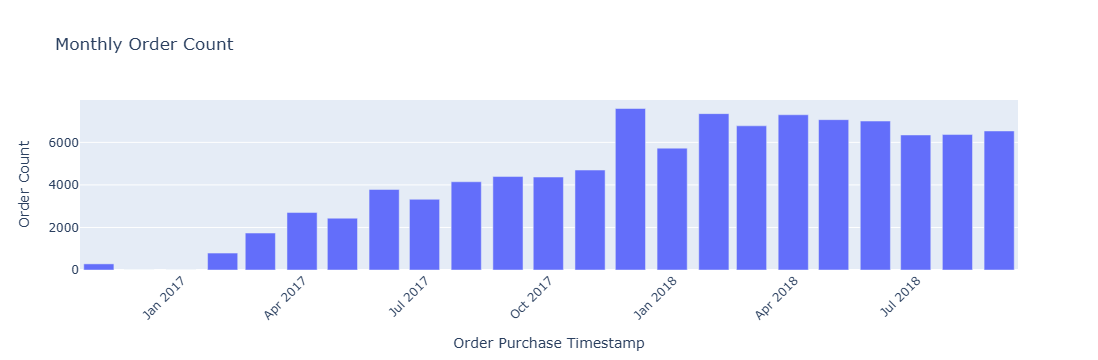

In [21]:
import plotly.express as px

fig = px.bar(
    x= merged_order_month_count.index,
    y= merged_order_month_count["payment_value"],
    title= "Monthly Order Count",
    labels = {
        "x": "Order Purchase Timestamp",
        "y": "Order Count"
    }
)
fig.update_layout(
    xaxis_tickangle= -45
)

fig.show()

In [ ]:
#월간 판매매출에 대한 비율: 월간 판매거래횟수와 거의 비례한다. => 인사이트

In [22]:
#일간 매출 내역 : 
merged_order_date_sum = merged_order_payment_date.groupby(pd.Grouper(freq= "D")).sum()

In [23]:
merged_order_date_sum.head()

,payment_value
order_purchase_timestamp,
2016-10-03,595.14
2016-10-04,9821.42
2016-10-05,7209.50
2016-10-06,6733.52
2016-10-07,7096.69


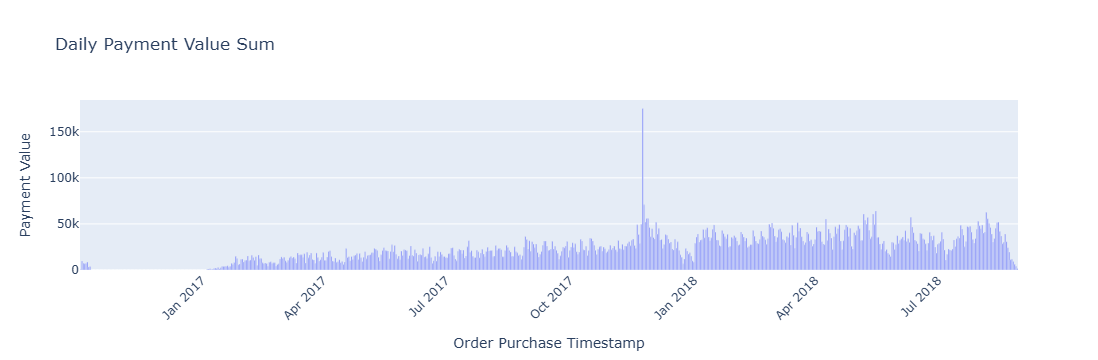

In [26]:
#일간 매출 내역 시각화: 

import plotly.express as px

fig = px.bar(
    x = merged_order_date_sum.index,
    y = merged_order_date_sum["payment_value"],
    title = "Daily Payment Value Sum",
    labels ={
        "x" :"Order Purchase Timestamp",
        "y" : "Payment Value"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [27]:
merged_order_date_count = merged_order_payment_date.groupby(pd.Grouper(freq= "D")).count()

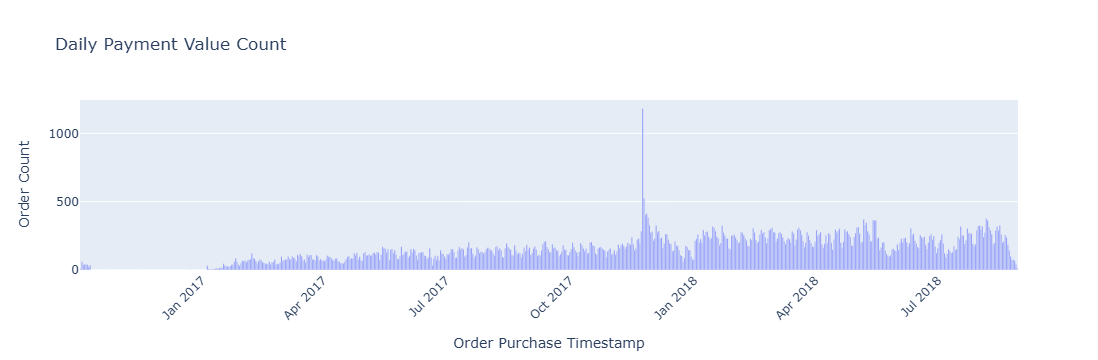

In [29]:
#일간 매출 내역 시각화: 

import plotly.express as px

fig = px.bar(
    x = merged_order_date_count.index,
    y = merged_order_date_count["payment_value"],
    title = "Daily Payment Value Count",
    labels ={
        "x" :"Order Purchase Timestamp",
        "y" :"Order Count"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [28]:
merged_order_date_count

,payment_value
order_purchase_timestamp,
2016-10-03,8
2016-10-04,61
2016-10-05,38
2016-10-06,41
2016-10-07,40
...,...
2018-08-25,71
2018-08-26,76
2018-08-27,68


In [32]:
#시간대별 판매 분석

merged_order_payment_date = merged_order[["order_purchase_timestamp","payment_value"]].copy()
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12


In [35]:
#형변환
# merged_order_payment_date.info()  #==> 문자열

merged_order_payment_date["order_purchase_timestamp"]= pd.to_datetime(merged_order_payment_date["order_purchase_timestamp"], format = "%Y-%m-%d %H:%M:%S", errors="raise")

In [39]:
merged_order_payment_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100739 entries, 0 to 100738
Data columns (total 2 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_purchase_timestamp  100739 non-null  datetime64[ns]
 1   payment_value             100739 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.5 MB


In [ ]:
# 파이썬 안에 있는 각 변수의 타입 & 해당 타입에서 사용가능한 속성 및 미셔드 등을 확인하고자 할때 dir()

In [43]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12


In [42]:
dir(merged_order_payment_date["order_purchase_timestamp"].dt)
#__,_ : 속성 => 객체.속성
#일반 문자열 : 매서드 => 객체.메서드()

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__frozen',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_add_delegate_accessors',
 '_constructor',
 '_delegate_method',
 '_delegate_property_get',
 '_delegate_property_set',
 '_dir_additions',
 '_dir_deletions',
 '_freeze',
 '_get_values',
 '_hidden_attrs',
 '_parent',
 '_reset_cache',
 'as_unit',
 'ceil',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'floor',
 'freq',
 'hour',
 'is_leap_year',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'is_quarter_start',
 'is_year_end',
 'is

In [45]:
#1/4, 2/4, 3/4, 4/4 =3개월 분기 나눌 수 있음
#각 요소들이 사용할 수 있는 속성 혹은 매서드를 조회 : dir()
#order_purchase_timestamp :dir() => dt(datetime) : 해당 날짜 요소의 속성값을 조회 -> 어떤 데이터만 추춘
#dt 안에 세부 속성 > year, month, quarter 등등

merged_order_payment_date["year"]= merged_order_payment_date["order_purchase_timestamp"].dt.year  #=> 해당 날짜데이터가 몇분기인지 알려줌
merged_order_payment_date["month"]= merged_order_payment_date["order_purchase_timestamp"].dt.month #월추출
merged_order_payment_date["quarter"]= merged_order_payment_date["order_purchase_timestamp"].dt.quarter  #분기추출
merged_order_payment_date["monthday"]= merged_order_payment_date["order_purchase_timestamp"].dt.day  #몇주차
merged_order_payment_date["weekday"]= merged_order_payment_date["order_purchase_timestamp"].dt.weekday  #요일
merged_order_payment_date["hour"]= merged_order_payment_date["order_purchase_timestamp"].dt.hour 
merged_order_payment_date["minute"]= merged_order_payment_date["order_purchase_timestamp"].dt.minute 

In [46]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value,year,month,quarter,monthday,weekday,hour,minute
0,2017-10-02 10:56:33,18.12,2017,10,4,2,0,10,56
1,2017-10-02 10:56:33,2.00,2017,10,4,2,0,10,56
2,2017-10-02 10:56:33,18.59,2017,10,4,2,0,10,56
3,2018-07-24 20:41:37,141.46,2018,7,3,24,1,20,41
4,2018-08-08 08:38:49,179.12,2018,8,3,8,2,8,38


In [ ]:
# weekday 읽는 법: 
#0:월요일 / 1: 화 / 2:수/ .../ 6: 일
#일반적 프로그래밍 언어 : - -> 일요일로 인식
#데이터를 취급ㅎ하는 언어, 프로그램-> 0: 월요일 인식

In [49]:
#연도별 추이
merged_order_payment_year = merged_order_payment_date[["year", "payment_value"]].copy()
merged_order_payment_year

,year,payment_value
0,2017,18.12
1,2017,2.00
2,2017,18.59
3,2018,141.46
4,2018,179.12
...,...,...
100734,2017,85.08
100735,2018,195.00
100736,2017,271.01
100737,2018,441.16


In [50]:
merged_order_payment_year = merged_order_payment_year.groupby("year").sum()
merged_order_payment_year.head()

,payment_value
year,
2016,47290.82
2017,6920422.83
2018,8451969.20


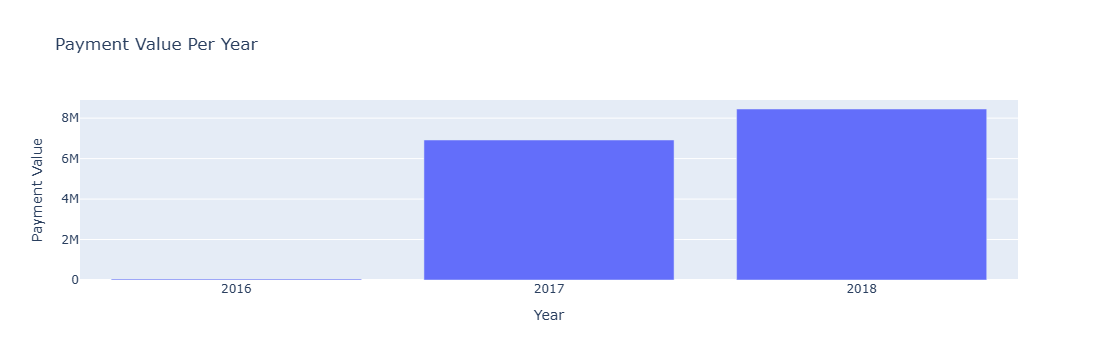

In [54]:
#연도별 추이 시각화
import plotly.express as px

fig = px.bar(
    x=merged_order_payment_year.index,
    y=merged_order_payment_year["payment_value"],
    title = "Payment Value Per Year",
    labels = {
        "x" : "Year",
        "y" : "Payment Value"
    }
)

fig.update_xaxes(
    tickvals=[2016,2017,2018]
)
fig.show()

In [56]:
#요일별 추이
merged_order_payment_weekday = merged_order_payment_date[["weekday","payment_value"]].copy()

In [59]:
merged_order_payment_weekday = merged_order_payment_weekday.groupby("weekday").sum()
merged_order_payment_weekday

,payment_value
weekday,
0,2530671.56
1,2473930.77
2,2396215.34
3,2283849.51
4,2222421.36
5,1704949.69
6,1807644.62


In [60]:
#인덱스에서 밖으로 끄집어내기

merged_order_payment_weekday = merged_order_payment_weekday.reset_index()

In [61]:
merged_order_payment_weekday

,weekday,payment_value
0,0,2530671.56
1,1,2473930.77
2,2,2396215.34
3,3,2283849.51
4,4,2222421.36
5,5,1704949.69
6,6,1807644.62


In [62]:
#apply() => 각 행마다 어떤 기능을 적용하고 싶은데 행마다 반복적으로 적용할 수 있도록 해주는 함수
# 0 -> 월요일 (0 값이 같은 문자열이어야함)

merged_order_payment_weekday.info()  #=> weekday 값은 정수형태  #==> 형변환 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        7 non-null      int32  
 1   payment_value  7 non-null      float64
dtypes: float64(1), int32(1)
memory usage: 216.0 bytes


In [63]:
merged_order_payment_weekday["weekday"] = merged_order_payment_weekday["weekday"].astype(object)

In [64]:
merged_order_payment_weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        7 non-null      object 
 1   payment_value  7 non-null      float64
dtypes: float64(1), object(1)
memory usage: 244.0+ bytes


In [65]:
#함수정의 요일 표시

def func(row) :
    if row["weekday"] == 0 : 
        row["weekday"] = "Mon"
    elif row["weekday"] == 1 : 
        row["weekday"] = "Tue"
    elif row["weekday"] == 2 : 
        row["weekday"] = "Wed"
    elif row["weekday"] == 3 : 
        row["weekday"] = "Thu"
    elif row["weekday"] == 4 : 
        row["weekday"] = "Fri"
    elif row["weekday"] == 5 : 
        row["weekday"] = "Sat"
    elif row["weekday"] == 6 : 
        row["weekday"] = "Sun"

    return row

In [66]:
merged_order_payment_weekday =  merged_order_payment_weekday.apply(func, axis=1)

In [67]:
merged_order_payment_weekday

,weekday,payment_value
0,Mon,2530671.56
1,Tue,2473930.77
2,Wed,2396215.34
3,Thu,2283849.51
4,Fri,2222421.36
5,Sat,1704949.69
6,Sun,1807644.62


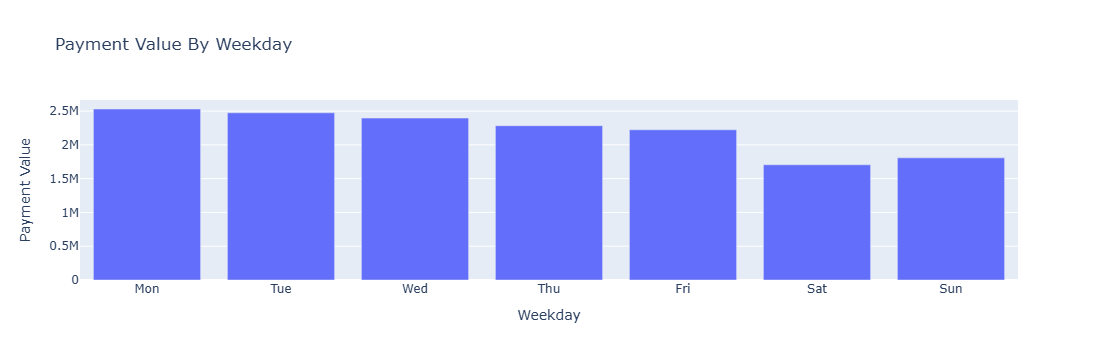

In [69]:
#시각화
import plotly.express as px

fig= px.bar(
    x= merged_order_payment_weekday["weekday"],
    y= merged_order_payment_weekday["payment_value"],
    title = "Payment Value By Weekday",
    labels = {
        "x": "Weekday",
        "y": "Payment Value"
    }
)

fig.show()